## SMBHB MODEL 
This notebook provides the photometric model of Super Massive Black Hole Binaries for two components: Doppler boosting and Stochastic Quasar Variability

## 1. Importing python libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib notebook
from astropy.time import Time
from astropy import units as u
from astropy import constants as c
from ipywidgets import *

## 2. Model Component- Doppler Boosting

We start off by modelling the light curve of SMBHB as a result of the doppler boosting effect. 

In [2]:
def calculate_eccentric_anomaly(M_A, e):
    
    """
    We use Kepler's equation (M = E – e sin E) to determine the Eccentric anomaly E.
    Newton Raphson method is used to obtain the eccentric anomaly
   
    Parameters
    ---------------------
    M = mean anomaly
    e = eccentricity
    """
    
    # Initialize E with M
    E = M_A
    tol = 1e-12 * u.rad
    max_iterations = 1000  

    for _ in range(max_iterations):
        E_next = E - (E - e * np.sin(E) * u.rad - M_A) / (1 - e * np.cos(E))
        if np.allclose(E_next, E, atol=tol):
            return E_next
        E = E_next

    raise Exception("Eccentric anomaly solver did not converge.")
    

    
def doppler_boosting(time, P, M1, M2, e, i, w, t0):
    """ 
    generates relative flux caused by the doppler boosting effect

    Parameters
    ---------------
    time: time array for the light curve
    P: Orbital period
    M1: Mass of primary Black hole
    M2: Mass of secondary Black hole
    e: eccentricity
    i: inclination angle
    w: argument of periapse
    t0: arbitrary reference time
    alpha: spectral index
    
    -->Starts by Calculating mean anomaly
    -->Then calls the eccentric anomaly used to calculate true anomaly 'f' 
    -->Radial velocity RV2 of secondary Black Hole is used to calculate flux    
    """
    
    mean_anomaly = 2 * np.pi * (time - t0) / P * u.rad
    E = calculate_eccentric_anomaly(mean_anomaly, e)

    
    M = G * (M1 + M2)  
    
    
    phi = 2 * np.pi * (time - t0) / P * u.rad
    a = M**(1/3)*((P/(2*np.pi))**(2/3))
    
    
    
    f =  2*np.arctan(np.sqrt((1 + e) / (1 - e)) * np.tan(E/2))  
    K2 = (2 * np.pi / P) * (M1/(M1+M2)) * a * np.sin(i) / np.sqrt(1 - e**2)
    RV2 = K2 * (np.cos(w + f) + e * np.cos(w))    
    MN = (0.89)*(3 - alpha) * (-RV2 / c_phot) + 1

    
    return MN



## 3. Stochastic Quasar Variability
The stochastic quasar variability is best described by the damped random walk model. 
We use the power spectral density(PSD) for Damped Random Walk to generate the model light curve

In [3]:
def getRedNoise(time, currenttime, kicktimestep, Ntime, timescale, varscale, noise, mu, sigma):

    
    signal = np.zeros(Ntime)
    
    for i in range(Ntime):
    

        # Compute the contribution of each component separately.
        # First advance the time series right *before* the time point i,

        while( (currenttime + kicktimestep) < time[i]):
            noise = noise * (1.0 - kicktimestep/timescale) + np.random.normal(mu[0], sigma[0])
            currenttime = currenttime + kicktimestep

        # Then advance the time series with a small time step right *on* time[i]

        delta  = time[i] - currenttime
        #sigma1 = np.sqrt(delta/timescale)*varscale
        sigma1 = varscale * 0.66  # Correction factor to have varscale in RMS arcsec
        noise  = noise * (1.0 - delta/timescale) + np.random.normal(mu[0], sigma1)
        currenttime = time[i]

        # Add the different components to the signal. 

        signal[i] = np.sum(noise)*1e-6 

    return signal


#is tau and sigma dependent on orbital properties of binary or from the the properties of the black hole itself


def modelRedNoise(time, timescale, varscale):

    """Function to generate a red noise time series.
    
    Parameters
    ----------
    time : ndarray
        Time points: time[0..Ntime-1]
    timescale : ndarray
        Time scale tau of each red noise component: timescale[0..Ncomp-1]
    varscale : ndarray
        Variation scale of each red noise component: varscale[0..Ncomp-1]
            
    Returns
    -------
    signal : ndarray
        Signal containing all red noise components: signal[0..Ntime-1]
    """

    Ntime = len(time)
    Ncomp = len(timescale)

    # Set the kick (= excitation) timestep to be one 100th of the
    # shortest noise time scale (i.e. kick often enough).

    kicktimestep = min(timescale) / 100.0
    currenttime  = time[0] - kicktimestep
    
    # Predefine some arrays

    delta = 0.0
    noise = np.zeros(Ncomp)
    mu    = np.zeros(Ncomp)
    sigma = np.sqrt(kicktimestep/timescale)*varscale
    
    # Warm up the first-order autoregressive process

    for i in range(2000):
        noise = noise * (1.0 - kicktimestep / timescale) + np.random.normal(mu, sigma)

    # Start simulating the granulation time series
    
    return getRedNoise(time, currenttime, kicktimestep, Ntime,
                       timescale, varscale, noise, mu, sigma)
    


def modelRedNoisePSD(freq, timescale, varscale):

    """Function to generate a red noise model from the PSD.

    Compute the mean power spectral density (PSD) corresponding to the 
    red noise time series that is generated by modelRedNoise().

    INPUT: freq:       frequency points of the PSD  [microHz | mHz | Hz]
           timescale:  see the function rednoise()
           varscale:   see the function rednoise()

    OUTPUT: psd:  power spectral density   [ppm^2/microHz | ppm^2/microHz | ppm^2/microHz]
    """

    psd = np.zeros_like(1 / (freq**2))  

    for n in range(len(timescale)):
        sigma = varscale[n] 
        tau = timescale[n]
        num =  sigma * sigma * tau * tau * 2
        denom = (1.0  + (2.0*np.pi*freq*tau)**2)
        psd += num / denom
    
    return psd



## 4. Constants and SPIKEY Parameters 
Finally we define our constants and parameters of the SPIKEY SMBHB. We also define the time series here and convert necessary units from (seconds) to Modified Julian Date for a better comparison with the light curve produced by Hu et.al  

In [4]:
# Constants (in SI units)
G = c.G
h = c.h                                                       
c_phot = c.c                                                                   
                                                              

# Parameters relating to Spikey (SI)
alpha = 2.09                                               
P = 1.144 * 365.25 * 86400 * u.s                                        
M2 = 10**36.7 * u.kg                                                           
M1 = 10**37.4 * u.kg                                                           
i =  1.4296097932 * u.rad
e = 0.524
w = 1.477 * u.rad
t0 = 1.693 * 365.25 * 86400 * u.s


time = np.arange(0, 36101894.4, 25)                           
time *= u.s
time_d = time.to(u.d)
reference_mjd = 55365 * u.day
t_mjd = reference_mjd + time_d


## 5. Plotting the doppler boosting model
Run the boosting model and plot it, then the DRW model and plot its frequency distribution, then both models together

<IPython.core.display.Javascript object>


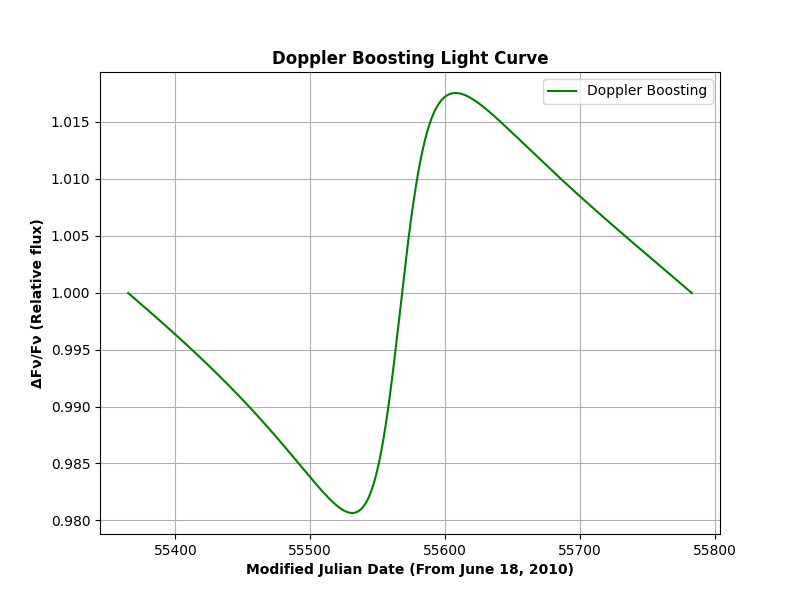

In [5]:
beam = doppler_boosting(time, P, M1, M2, e, i, w, t0)


plt.figure(figsize=(8, 6))
plt.plot(t_mjd, beam, color='green', label="Doppler Boosting")
plt.xlabel("Modified Julian Date (From June 18, 2010)", fontweight='bold')
plt.ylabel("ΔFν/Fν (Relative flux)", fontweight='bold')
plt.title("Doppler Boosting Light Curve", fontweight='bold')
plt.grid(True)
plt.legend()
plt.show()

## 6. Plotting the PSD as a function of frequency

/lhome/nicholas/anaconda3/envs/platonium/lib/python3.9/site-packages/astropy/units/quantity.py:666: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


<IPython.core.display.Javascript object>


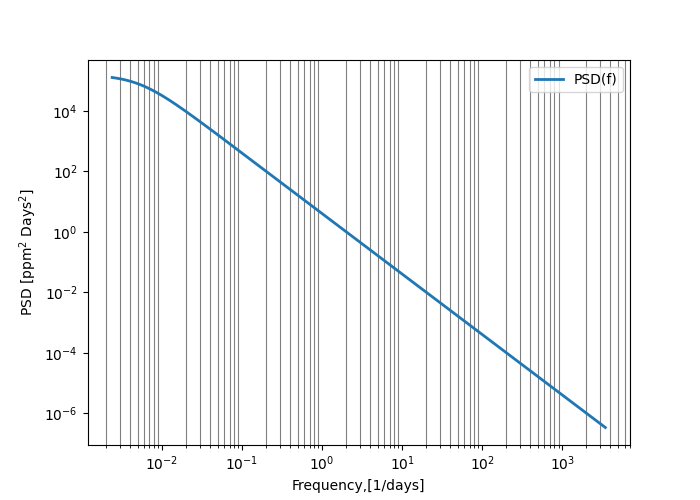

In [6]:
freq = 1/time_d
tau   = np.array([31])   
tau *= u.day
sigma = np.array([9])                                      # ppm

#Get the signal and the psd
sign = modelRedNoise(time_d, tau, sigma)        

# Plot of  frequency model

fig = plt.figure(figsize = (7, 5))
for i in range(len(tau)):
    plt.loglog(freq, modelRedNoisePSD(freq, tau, sigma), lw=2, 
               label= "PSD(f)")
plt.grid(True, which='minor', axis='both', linestyle='-', color='gray')
plt.xlabel(r"Frequency,[1/days]")
plt.ylabel(r"PSD [ppm$^2$ Days$^2$]")
plt.legend()
plt.show()

## 7. Plotting the combined (Doppler + Stochastic Quasar Variability) model

<IPython.core.display.Javascript object>


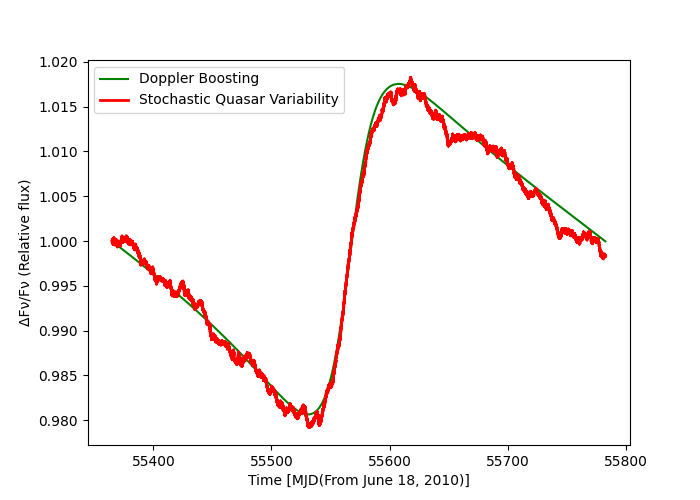

In [7]:
# Plot of boosting + rednoise
redboost = sign + beam

fig = plt.figure(figsize = (7, 5))
plt.plot(t_mjd, beam, color='green', label="Doppler Boosting")
for i in range(len(tau)):
    plt.plot(t_mjd, redboost, lw=2, color = 'red', 
               label="Stochastic Quasar Variability")

plt.grid(True, which='minor', axis='both', linestyle='-', color='gray')
plt.xlabel(r"Time [MJD(From June 18, 2010)]")
plt.ylabel(r"ΔFν/Fν (Relative flux)")
plt.legend()
plt.show()